In [124]:
import Plots
using Measures
Plots.plotlyjs()  # switch to the interactive backend
include("proportional_solver.jl")

logarithmic_norm (generic function with 1 method)

In [9]:
include("proportional_solver.jl")

logarithmic_norm (generic function with 1 method)

In [116]:
Plots.plotlyjs()  # switch to the interactive backend

Plots.PlotlyJSBackend()

# 1D Unstable System

TODO

In [22]:
# TODO

# 2D Inverted Pendulum

A 2D inverted pendulum dynamics can be linearized around the equelibrium point to 
$$\begin{aligned}
\begin{bmatrix}\dot{\omega}\\\dot{\theta} \end{bmatrix} &= \begin{bmatrix}-b & a\\ 1 & 0 \end{bmatrix} \begin{bmatrix}\omega\\\theta \end{bmatrix} + \begin{bmatrix}c\\0 \end{bmatrix}u\\
y &= \begin{bmatrix}0 & 1 \end{bmatrix}\begin{bmatrix}\omega\\\theta \end{bmatrix}
\end{aligned}$$

and all $K> a/b$ stabilize the system, with $K=a/b + b^2/(4c)$ being the lowest choice with minimal negative real part.

In [129]:
a = 1
b = 2
c = 1

A = [-b a; 1.0 0]
B = [c; 0;;]
C = [0 1.0]
g = 0.5
K = (1+g)*a/c + (b^2)/(4c)

eigvals(A - B*K*C)

2-element Vector{ComplexF64}:
 -1.0 - 0.7071067811865475im
 -1.0 + 0.7071067811865475im

In [131]:
a3 = 1
b3 = 2
c3 = 1
d3 = 1
e3 = 1
f3 = 2

A3 = [-b3 a3 d3; 1.0 0 0; -e3 0 -f3]
B3 = [0; 0; c3;;]
C3 = [0 1.0 0]

a2, a1 = b3 + f3, b3*f3 + d3*e3 - a3
kofp(p) = (a3*f3 + p*(p^2 - a2*p + a1))/(c3*d3)       # place a pole at -p
g3 = 0.5
K3 = kofp(g3)

eigvals(A3 - B3*K3*C3)

3-element Vector{Float64}:
 -2.651387818865998
 -0.8486121811340039
 -0.4999999999999989

4.125

In [14]:
include("zoh_solver.jl")

demo (generic function with 1 method)

In [23]:
min_sampling_frequency(A, B, C, reshape([K], 1, 1); sgn=-1, margin=0.002)

continuous closed loop: max Re λ = -0.25
  eigenvalues: ComplexF64[-0.25 - 1.0im, -0.25 + 1.0im]
critical sampling period  h_max = 0.4861379553 s
minimum sampling frequency f_min = 2.057029263 Hz  (12.92469604 rad/s)
check: ρ(M(0.99 h_max)) = 0.996968,  ρ(M(1.01 h_max)) = 0.999050


(h_max = 0.4861379552879511, f_min = 2.0570292632421103, ω_min = 12.924696043241276, rho_at_h_max = 0.998000000000008)

In [42]:
# Choose the optimal starting point for the optimization
k_vec = 0.0:0.01:2.0
I0vec = zeros(length(k_vec))
for (i, k) in enumerate(k_vec)
    K = (1+k)*a/c + (b^2)/(4c)
    system = SpikingSystem(A, B, C, K)
    optimize_lambda_0!(system)
    optimize_for_starting_point!(system, x0)
    I0vec[i] = system.I0
end

In [67]:
system = SpikingSystem(A, B, C, K)

SpikingSystem([-0.5 1.0; 1.0 0.0], [0.5; 0.0;;], [0.0 1.0], 4.125, [0.0 0.0; 0.0 0.0], [0.0 0.0; 0.0 0.0], -1.0, -1.0, -1.0, -1.0, -1.0, var"#44#45"(), var"#46#47"())

In [132]:
system3 = SpikingSystem(A3, B3, C3, K3)

SpikingSystem([-2.0 1.0 1.0; 1.0 0.0 0.0; -1.0 0.0 -2.0], [0.0; 0.0; 1.0;;], [0.0 1.0 0.0], 3.125, [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], [0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0], -1.0, -1.0, -1.0, -1.0, -1.0, var"#64#65"(), var"#66#67"())

In [133]:
optimize_lambda_0!(system)
optimize_lambda_0!(system3)

SpikingSystem([-2.0 1.0 1.0; 1.0 0.0 0.0; -1.0 0.0 -2.0], [0.0; 0.0; 1.0;;], [0.0 1.0 0.0], 3.125, [1.9813284565136338 4.180211608473048 0.7175547660355237; 4.18021160842055 10.1191217261124 1.4976679628239147; 0.7175547660252639 1.4976679627279705 0.6087775411037313], [1.0000001412217139 -3.590909680255245e-7 1.8590827734597585e-7; -3.591320806083298e-7 1.0000015504560438 -6.328590808313317e-7; 1.8596318193678014e-7 -6.330932061098669e-7 1.0000006323541406], 0.08248949550708919, -1.0, -1.0, -1.0, -1.0, var"#71#72"{Matrix{Float64}}([1.9813284565136338 4.180211608473048 0.7175547660355237; 4.18021160842055 10.1191217261124 1.4976679628239147; 0.7175547660252639 1.4976679627279705 0.6087775411037313]), var"#73#74"{Matrix{Float64}}([0.9024847689192294 1.0565032384876278 0.22505689383209004; 1.0565032384704471 2.980485932227935 0.34587026613825045; 0.22505689385166555 0.34587026610517263 0.6621938497531327]))

In [136]:
x0 = [0.5; 0.5]

optimize_for_starting_point!(system, x0)

x03 = [x0; 0]

optimize_for_starting_point!(system3, x03)

SpikingSystem([-2.0 1.0 1.0; 1.0 0.0 0.0; -1.0 0.0 -2.0], [0.0; 0.0; 1.0;;], [0.0 1.0 0.0], 3.125, [1.9813284565136338 4.180211608473048 0.7175547660355237; 4.18021160842055 10.1191217261124 1.4976679628239147; 0.7175547660252639 1.4976679627279705 0.6087775411037313], [1.0000001412217139 -3.590909680255245e-7 1.8590827734597585e-7; -3.591320806083298e-7 1.0000015504560438 -6.328590808313317e-7; 1.8596318193678014e-7 -6.330932061098669e-7 1.0000006323541406], 0.08248949550708919, 0.03614815592031701, 0.004763220188416183, 3.614737777992059, 2367.8817436742147, var"#71#72"{Matrix{Float64}}([1.9813284565136338 4.180211608473048 0.7175547660355237; 4.18021160842055 10.1191217261124 1.4976679628239147; 0.7175547660252639 1.4976679627279705 0.6087775411037313]), var"#73#74"{Matrix{Float64}}([0.9024847689192294 1.0565032384876278 0.22505689383209004; 1.0565032384704471 2.980485932227935 0.34587026613825045; 0.22505689385166555 0.34587026610517263 0.6621938497531327]))

In [138]:
system3.Delta

3.614737777992059

In [139]:
system3.I0

2367.8817436742147

In [20]:
system.I0 = system.I0*20
system.Delta = system.Delta*20

0.13475658019900102

In [40]:
system.I0 = system.I0*2

0.8657485737178632

In [29]:
system.alpha = system.alpha*2
system.I0 = system.I0/2

0.8657485737178632

In [73]:
system.I0/system.PVecNorm(x0)

60.861748909517615

In [150]:
tspan = (0.0, 50.0)
x0 = 5*[-0.5; 0.5; 0]

sol = simulate_from_starting_point(system3, x0; tspan=tspan, callbackargs=(interp_points=100,), solverargs=(dtmax=0.1*system3.Delta/system3.I0,))

relaxed_system3 = deepcopy(system3)
relaxed_system3.I0 = system3.I0/4000
relaxed_system3.Delta = system3.Delta/10
relaxed_system3.alpha = system3.alpha*400

sol_relaxed = simulate_from_starting_point(relaxed_system3, x0; tspan=tspan, callbackargs=(interp_points=100,), solverargs=(dtmax=0.1*system3.Delta/system3.I0,))

sol_cont = simulate_ideal_from_starting_point(system3, x0; tspan=tspan, solverargs=(dtmax=0.1 * system3.Delta / system3.I0,))

retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 327533-element Vector{Float64}:
  0.0
  0.00015265702299740327
  0.00030531404599480654
  0.0004579710689922098
  0.0006106280919896131
  0.0007632851149870164
  0.0009159421379844197
  0.0010685991609818229
  0.0012212561839792262
  0.0013739132069766295
  ⋮
 49.99883879987542
 49.998991456898416
 49.99914411392141
 49.999296770944404
 49.9994494279674
 49.99960208499039
 49.99975474201339
 49.99990739903638
 50.0
u: 327533-element Vector{Vector{Float64}}:
 [-2.5, 2.5, 0.0]
 [-2.49885533810269, 2.499618444819607, -0.000810863003351837]
 [-2.497711207603832, 2.4992370643393276, -0.0016214711974089295]
 [-2.496567608275662, 2.498855858478058, -0.0024318246621735018]
 [-2.4954245398905104, 2.498474827154728, -0.003241923477619436]
 [-2.494282002220801, 2.4980939702883034, -0.0040517677236922844]
 [-2.493139995039052, 2.497713287797784, -0.00486135748030928]
 [-2.491998518117876, 2.497332779602204, -0.0056706928

In [153]:
# Compute norms
norms = zeros(length(sol.t))
norms_relaxed = zeros(length(sol_relaxed.t))
norms_cont = zeros(length(sol_cont.t))
for i in 1:length(sol.t)
    norms[i] = system3.PVecNorm(sol[2:4, i])
end
for i in 1:length(sol_relaxed.t)
    norms_relaxed[i] = system3.PVecNorm(sol_relaxed[2:4, i])
end
for i in 1:length(sol_cont.t)
    norms_cont[i] = system3.PVecNorm(sol_cont[1:3, i])
end

largest_times = sol.t[1]:(system3.Delta/system3.I0):sol.t[end]
largest_norm = ones(size(largest_times))

mult = minimum_convergence(system3, x0)
start = system3.PVecNorm(x0)
for i in 1:length(largest_times)
    largest_norm[i] = start
    start = start * mult
end

In [27]:
Plots.gr()

Plots.GRBackend()

In [100]:
Plots.pgfplotsx()

Plots.PGFPlotsXBackend()

In [123]:
system.PVecNorm(x0)/relaxed_system.Delta

33.689703206484985

In [88]:
system.I0/system.Delta

51.396292333294525

In [97]:
relaxed_system.I0/relaxed_system.Delta

1.2849073083323634

In [85]:
relaxed_system.I0

0.3462994294871453

In [84]:
relaxed_system.Delta

0.13475658019900102

In [ ]:
p1 = Plots.plot(sol, idxs=(0, 3), label="Base system", title="Angle Trajectories", xlabel="Time", ylabel="theta", size=(500, 400), tickfontsize=10, legendfontsize=10)

p1 = Plots.plot!(sol_relaxed, idxs=(0, 3), label="Relaxed system", xlabel="Time")

p1 = Plots.plot!(sol_cont, idxs=(0, 2), label="Continuous system", xlabel="", legend=:topright)

In [ ]:
p12 = Plots.plot(sol, idxs=(0, 2), label="", title="Angular velocity Trajectories", xlabel="Time", ylabel="theta_dot", size=(500, 400), tickfontsize=10, legendfontsize=10)

p12 = Plots.plot!(sol_relaxed, idxs=(0, 2), label="", xlabel="Time")

p12 = Plots.plot!(sol_cont, idxs=(0, 1), label="", xlabel="", legend=:topright)

In [ ]:
p12 = Plots.plot(sol, idxs=(0, 4), label="", title="Motor Current Trajectories", xlabel="Time", ylabel="i", size=(500, 400), tickfontsize=10, legendfontsize=10)

p12 = Plots.plot!(sol_relaxed, idxs=(0, 4), label="", xlabel="Time")

p12 = Plots.plot!(sol_cont, idxs=(0, 3), label="", xlabel="", legend=:topright)

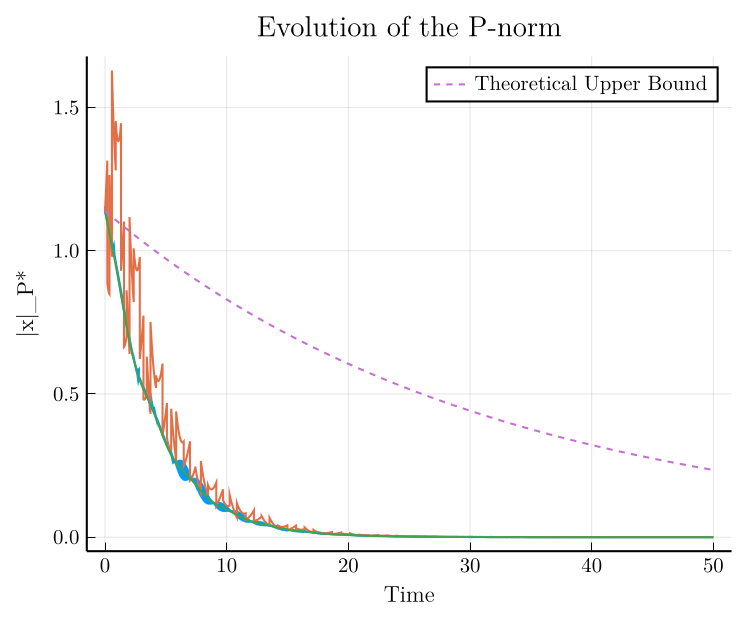

In [ ]:
p2 = Plots.plot(sol.t, norms, label="", title="Evolution of the P-norm", xlabel="Time", ylabel="|x|_P*", size=(500, 400), tickfontsize=10, legendfontsize=10)

p2 = Plots.plot!(sol_relaxed.t, norms_relaxed, label="")

p2 = Plots.plot!(sol_cont.t, norms_cont, label="")

p2 = Plots.plot!(largest_times, largest_norm, label="Theoretical Upper Bound", linestyle=:dash, legend=:topright)

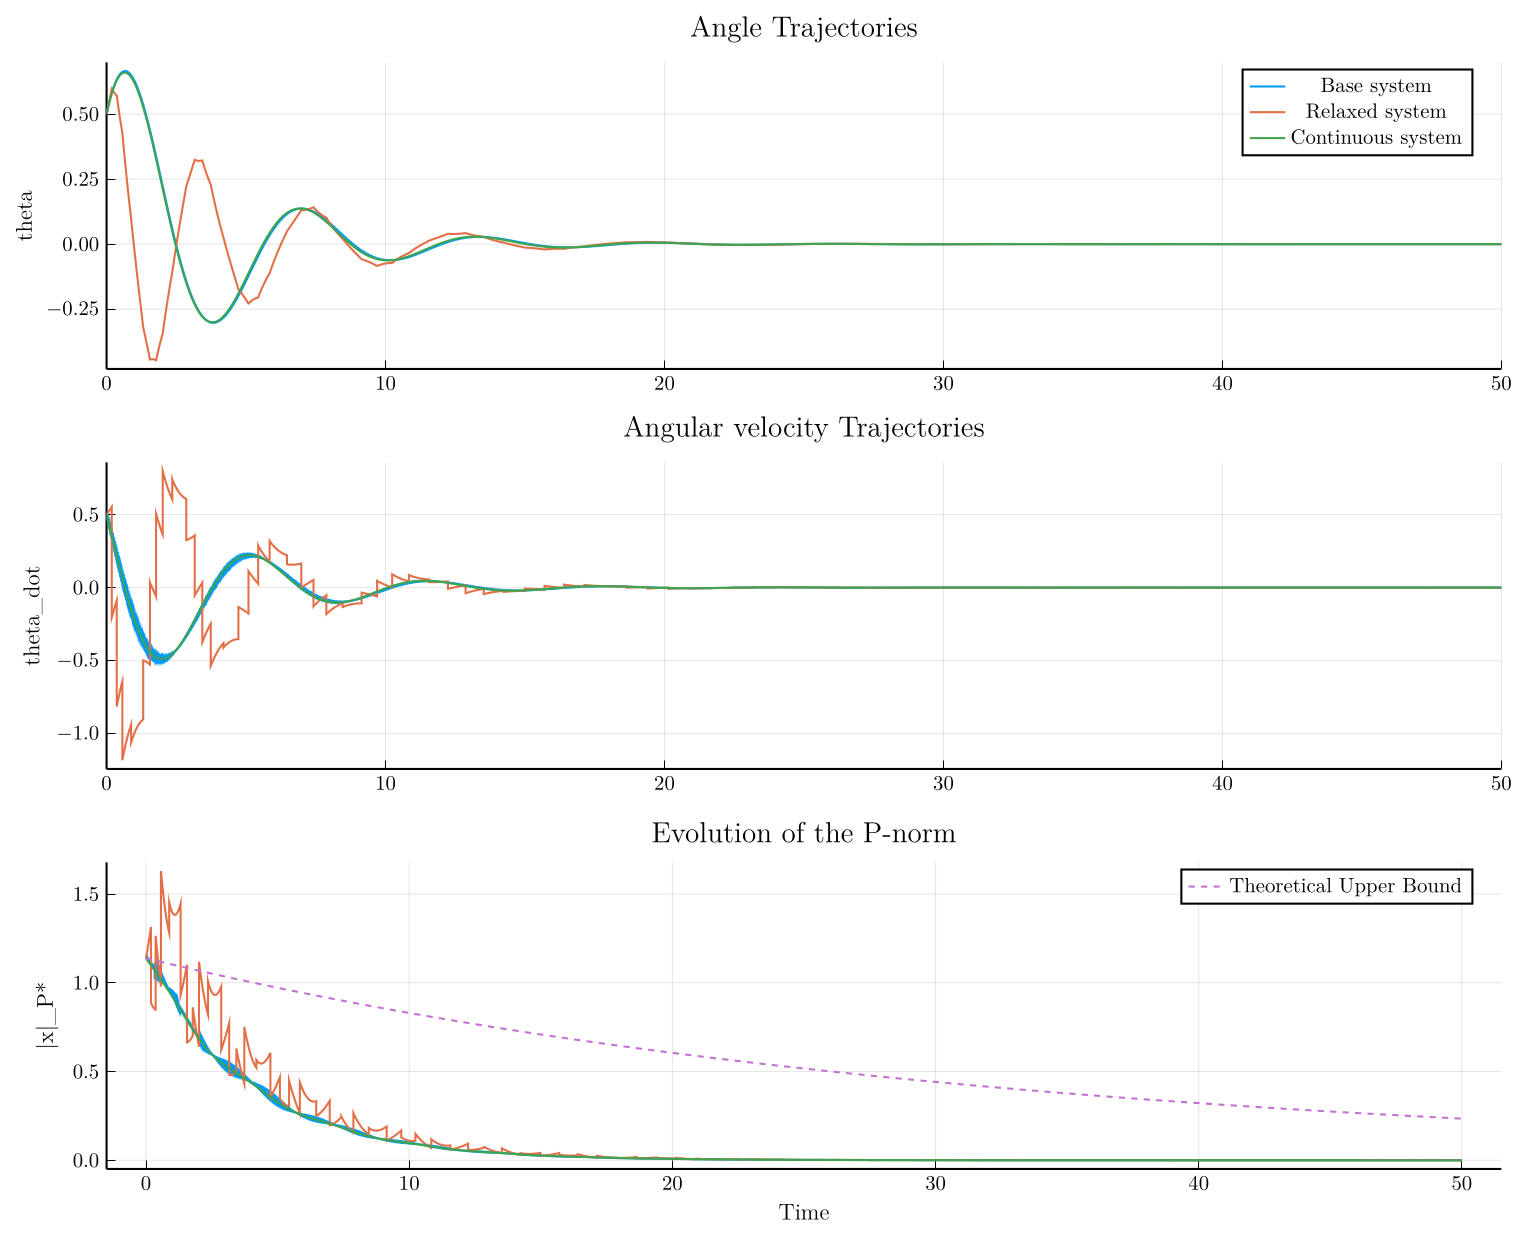

In [114]:
p = Plots.plot(p1, p12, p2, layout=(3, 1), bottom_margin=-5mm, top_margin=5mm, size=(1000, 800))

In [115]:
Plots.savefig(p, "invertedpendulum.pdf")

"c:\\Users\\chris\\OneDrive - Universite de Liege\\Docs\\PhD Research\\Hybrid System LIF sim emulation\\invertedpendulum.pdf"

In [206]:
system.alpha

0.10981636154947777

In [149]:
norms_relaxed

12274-element Vector{Float64}:
 1.1379871124044898
 1.1393417396504872
 1.141697126834803
 1.1440579304046972
 1.1464241573247658
 1.1485963364092424
 1.107856725416571
 1.1101740978808534
 1.1124965201349026
 1.1148240010265447
 ⋮
 0.002880322507276247
 0.0028776899286615046
 0.0028751049853162434
 0.0028725675945925214
 0.0028700776731985667
 0.0028676351371982453
 0.0028652399020107425
 0.002862895812987065
 0.003355501821878788

In [124]:
import Plots
import DifferentialEquations as DE

In [30]:
function dynamics!(du,u,p,t)
    du[1] = -u[1] - (sign(u[1] + 2*p(t)) + 1)/2
end

p(t) = 0.01*t - 1

u0 = [0.0]
tspan = (0.0, 200.0)

prob = DE.ODEProblem(dynamics!, u0, tspan, p)

ODEProblem with uType Vector{Float64} and tType Float64. In-place: true
Non-trivial mass matrix: false
timespan: (0.0, 200.0)
u0: 1-element Vector{Float64}:
 0.0

In [31]:
sol = DE.solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 4366-element Vector{Float64}:
   0.0
   9.999999999999999e-5
   1.0001
  11.000099999999998
  42.709442851214774
  89.82511035641777
  94.5843719651072
  98.39178125205873
  99.91474496683935
  99.93431108642346
   ⋮
 174.1994963967428
 178.19094394194008
 181.72954202986347
 185.0454821741544
 188.32877388645167
 191.682091484858
 195.13266263985852
 198.65805364027503
 200.0
u: 4366-element Vector{Vector{Float64}}:
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 [0.0]
 ⋮
 [-0.999728085717795]
 [-0.999374405845213]
 [-0.9993376743566578]
 [-0.999532609518355]
 [-0.9996894816121935]
 [-0.9997652492714311]
 [-0.9997879795796997]
 [-0.9997807873246093]
 [-0.9999423650681555]

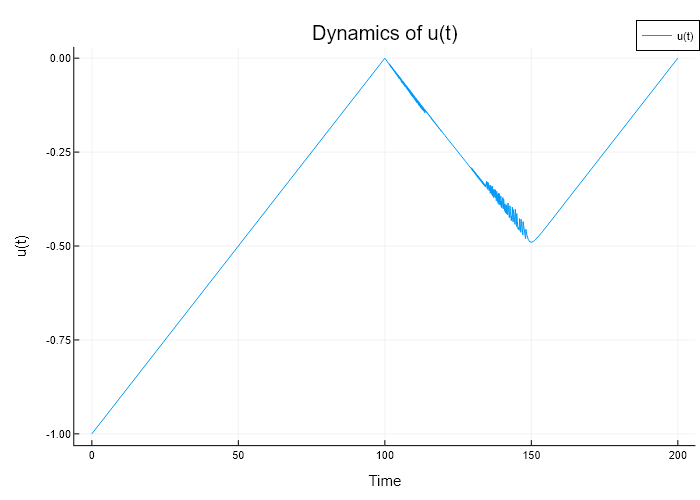

In [32]:
Plots.plot(sol.t, reduce(vcat, sol.u) + p.(sol.t), label="u(t)", title="Dynamics of u(t)", xlabel="Time", ylabel="u(t)")

In [ ]:
reduce(vcat, sol.u) + p.(sol.t)

60788-element Vector{Float64}:
 -1.0
 -0.9998990049998333
 -0.9941663637809575
 -0.944076508853734
 -0.8253062919281284
 -0.6681938104660208
 -0.5099003191398046
 -0.3555534465019057
 -0.22530813016836837
 -0.12366220435137076
  ⋮
 -0.2885418696553017
 -0.24477652809753514
 -0.20649691342224819
 -0.17226503363405943
 -0.13957952594682566
 -0.10667507148728084
 -0.07283211690887881
 -0.038018654183395895
 -2.7590966738655354e-5